C:\Users\Sanjay A\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.3181 - loss: 1.9129 - val_accuracy: 0.3940 - val_loss: 1.6975
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 17ms/step - accuracy: 0.4421 - loss: 1.5830 - val_accuracy: 0.4877 - val_loss: 1.4600
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.5105 - loss: 1.3841 - val_accuracy: 0.5216 - val_loss: 1.3439
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.5522 - loss: 1.2731 - val_accuracy: 0.5618 - val_loss: 1.2462
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.5792 - loss: 1.2018 - val_accuracy: 0.5707 - val_loss: 1.2247
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6002 - loss: 1.1430 - val_accuracy: 0.5843 - val_loss: 1.1702
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.6191 - loss: 1.0912 - val_accuracy: 0.6041 - val_loss: 1.1309
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.6364 -

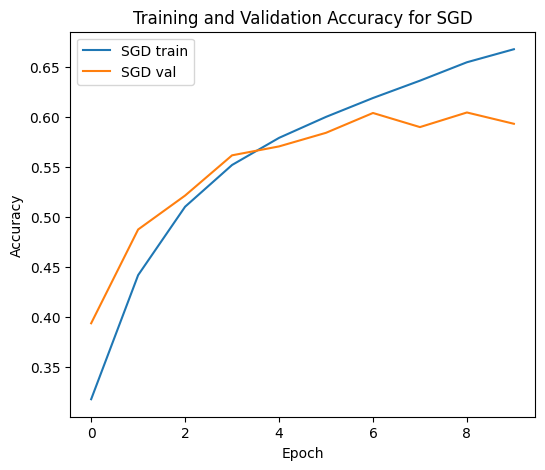

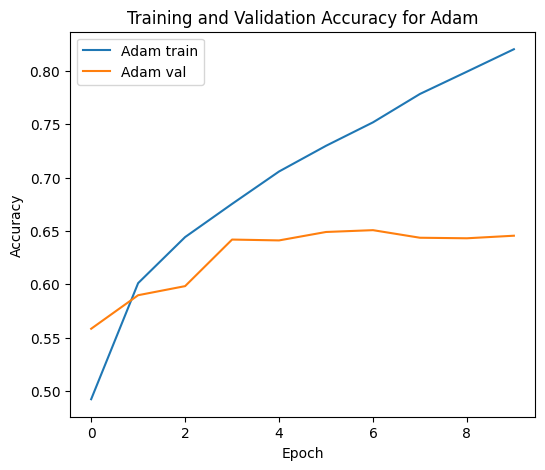

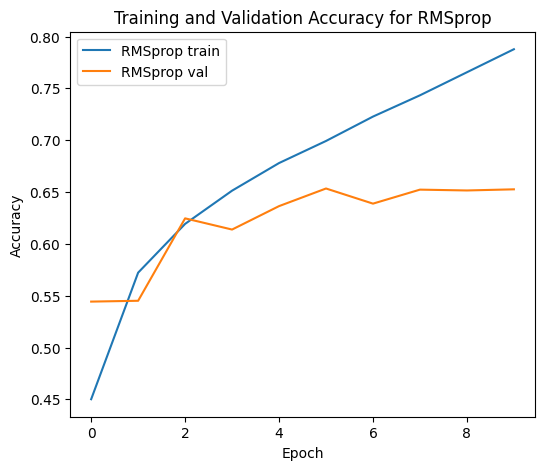

SGD - Train Accuracy: 0.6678, Validation Accuracy:0.5933
Adam - Train Accuracy: 0.8201, Validation Accuracy:0.6455
RMSprop - Train Accuracy: 0.7877, Validation Accuracy:0.6526


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0  


def build_and_train_model(optimizer, epochs=10):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())   
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=1,validation_data=(X_test, y_test))
    return history     

optimizers = {'SGD': SGD(), 'Adam': Adam(), 'RMSprop': RMSprop()}
histories = {name: build_and_train_model(optimizer) for name, optimizer in optimizers.items()}
for name in optimizers.keys():
    plt.figure(figsize=(6, 5))
    plt.plot(histories[name].history['accuracy'], label=f'{name} train')
    plt.plot(histories[name].history['val_accuracy'], label=f'{name} val')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'Training and Validation Accuracy for {name}')
    plt.show()
for name, history in histories.items():
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"{name} - Train Accuracy: {final_train_acc:.4f}, Validation Accuracy:{final_val_acc:.4f}")    